In [1]:
library(data.table)
library(ggplot2)
theme_set(theme_bw(20))
library(arrow)
library(Hmisc)
library(glue)



Attaching package: ‘arrow’


The following object is masked from ‘package:utils’:

    timestamp



Attaching package: ‘Hmisc’


The following objects are masked from ‘package:base’:

    format.pval, units




# STEM predictions stability checks

In [2]:
pred <- data.table(read_parquet("../data/stem_and_med_classifications.parquet"))

## Cross-country

In [4]:
  get_affiliation_pairs <- function(filename, pairtype1, pairtype2) {                                                                                                           
      aff_pair <- fread(filename)                                                                                                                                               
                                                                                                                                                                                
      # Detect column prefix from actual column names                                                                                                                           
      prefix   <- if ("same_country_affil" %in% names(aff_pair)) "country" else "period"
      same_affil <- paste0("same_", prefix, "_affil")                                                                                                                           
      diff_affil <- paste0("diff_", prefix, "_affil")
      same_sim   <- paste0("same_", prefix, "_cos_sim")                                                                                                                         
      diff_sim   <- paste0("diff_", prefix, "_cos_sim")
                                                                                                                                                                                
      print(glue("N unmatched Different: ", nrow(aff_pair[get(same_affil) == "" & get(diff_affil) != ""])))                                                                     
      print(glue("N unmatched Same: ",      nrow(aff_pair[get(same_affil) != "" & get(diff_affil) == ""])))
      print(glue("N unmatched both: ",      nrow(aff_pair[get(same_affil) == "" & get(diff_affil) == ""])))                                                                     
                                                                                                                                                                                
      aff_pair <- aff_pair[get(same_affil) != "" & get(diff_affil) != ""]                                                                                                       
      print(smean.cl.boot(aff_pair[[same_sim]]))                                                                                                                                
      print(smean.cl.boot(aff_pair[[diff_sim]]))                                                                                                                                
   
      same <- aff_pair[, .SD, .SDcols = c("anchor", same_affil, same_sim)]                                                                                                      
      setnames(same, c("anchor", "paired_affil", "cos_sim"))
      same$pair_type <- pairtype1                                                                                                                                               
                  
      diff <- aff_pair[, .SD, .SDcols = c("anchor", diff_affil, diff_sim)]                                                                                                      
      setnames(diff, c("anchor", "paired_affil", "cos_sim"))
      diff$pair_type <- pairtype2                                                                                                                                               
                  
      affil_data <- rbind(same, diff)                                                                                                                                           
   
      mg1 <- merge(affil_data, pred[, .(cmd, stem_pred)], by.x = "anchor",       by.y = "cmd", all.x = TRUE)                                                                    
      setnames(mg1, "stem_pred", "anchor_stem")
      mg2 <- merge(mg1,         pred[, .(cmd, stem_pred)], by.x = "paired_affil", by.y = "cmd", all.x = TRUE)                                                                   
      setnames(mg2, "stem_pred", "neighbor_stem")                                                                                                                               
      mg2[, stem_diff := abs(anchor_stem - neighbor_stem)]
      mg2$pair_type <- factor(mg2$pair_type)                                                                                                                                    
                                                                                                                                                                                
      return(mg2)
  }                                                                                                                                                                             
     

In [29]:
aff_pair_country <- get_affiliation_pairs("./affiliation_pairs_by_country.csv",
                                  ">1 Same Country User",
                                  "No Same Country User")
summary(lm(stem_diff~cos_sim+pair_type,data=aff_pair_country))

N unmatched Different: 48
N unmatched Same: 245
N unmatched both: 0
     Mean     Lower     Upper 
0.9001837 0.8986662 0.9016142 
     Mean     Lower     Upper 
0.8602757 0.8587503 0.8618117 



Call:
lm(formula = stem_diff ~ cos_sim + pair_type, data = aff_pair_country)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.30127 -0.08657 -0.04373  0.03704  0.80517 

Coefficients:
                               Estimate Std. Error t value Pr(>|t|)    
(Intercept)                    0.627990   0.012114  51.841   <2e-16 ***
cos_sim                       -0.590230   0.013348 -44.220   <2e-16 ***
pair_typeNo Same Country User  0.003031   0.002244   1.351    0.177    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1518 on 19411 degrees of freedom
Multiple R-squared:  0.0978,	Adjusted R-squared:  0.09771 
F-statistic:  1052 on 2 and 19411 DF,  p-value: < 2.2e-16


In [30]:
library(marginaleffects)

In [31]:
avg_predictions(lm(stem_diff~cos_sim+pair_type,data=aff_pair_country),newdata = "balanced",by="pair_type")

pair_type,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,df
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
>1 Same Country User,0.1084525,0.001564072,69.33985,0,Inf,0.1053870,0.1115180,Inf
No Same Country User,0.1114836,0.001564072,71.27779,0,Inf,0.1084181,0.1145491,Inf


`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


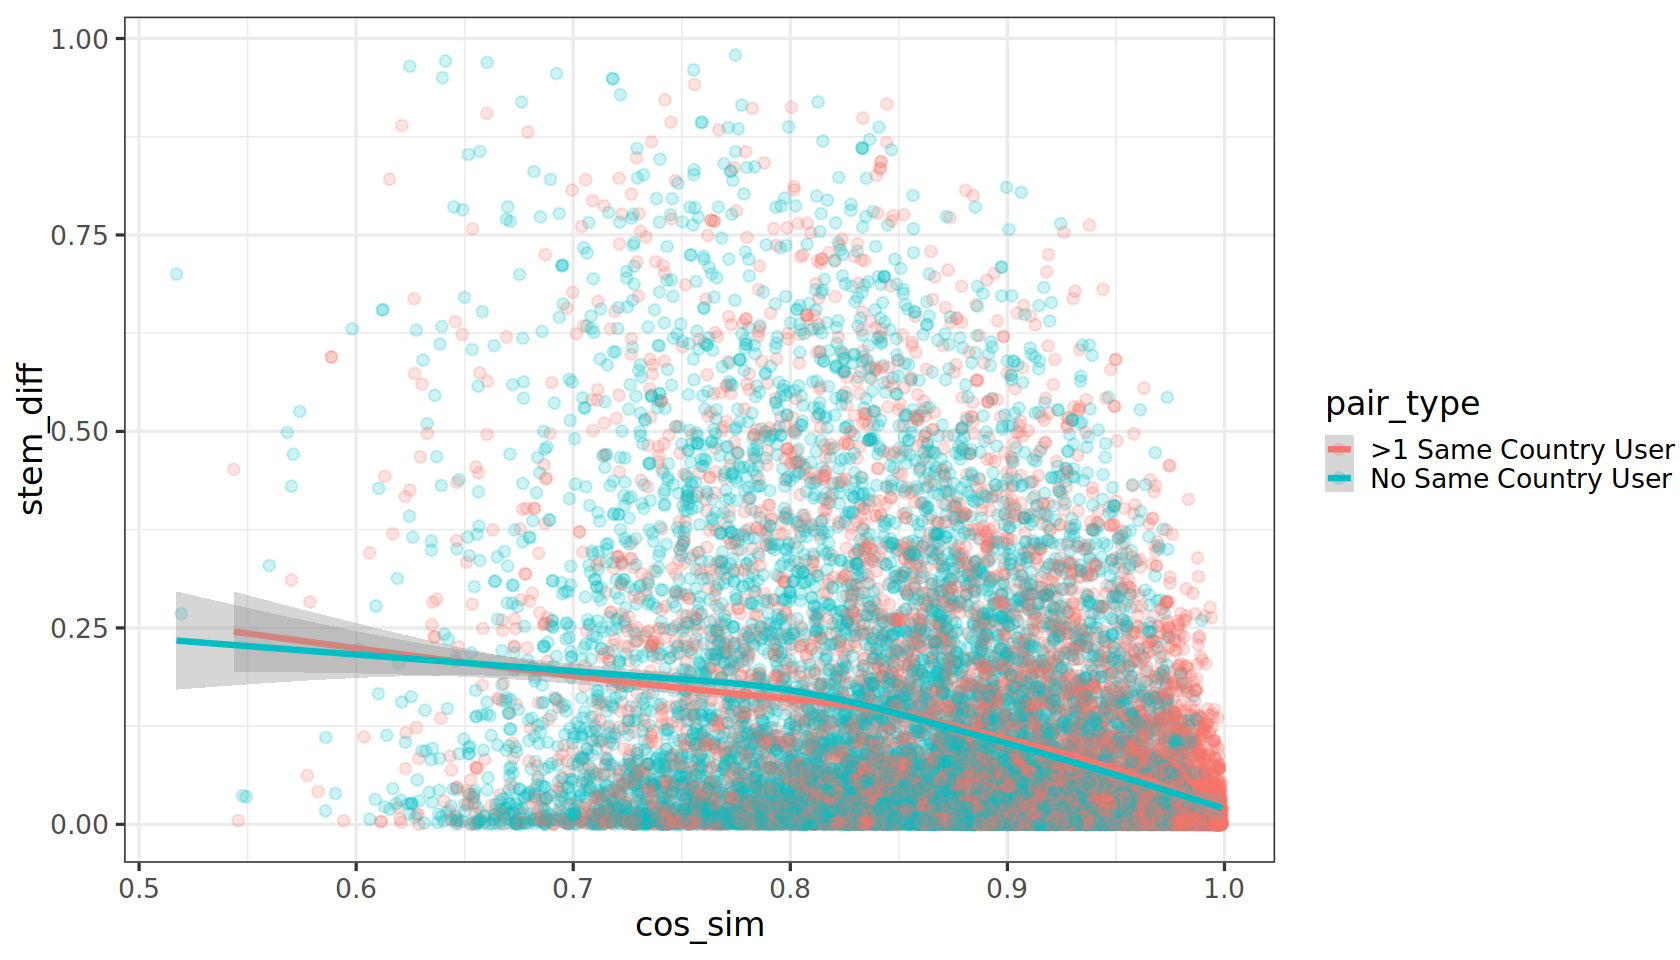

In [6]:
library(repr)
options(repr.plot.width=14, repr.plot.height=8)
ggplot(aff_pair_country, aes(cos_sim,stem_diff, color=pair_type))+geom_point(alpha=.2) + geom_smooth()

In [32]:
aff_pair_time <- get_affiliation_pairs("./affiliation_time_period_pairs.csv",
                                  ">1 Same Time Period",
                                  "No Same Time Period")
summary(lm(stem_diff~cos_sim+pair_type,data=aff_pair_time))

N unmatched Different: 0
N unmatched Same: 9320
N unmatched both: 4
     Mean     Lower     Upper 
0.8826133 0.8765461 0.8892530 
     Mean     Lower     Upper 
0.7320108 0.7249668 0.7392991 



Call:
lm(formula = stem_diff ~ cos_sim + pair_type, data = aff_pair_time)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.35990 -0.12161 -0.04990  0.06694  0.77027 

Coefficients:
                             Estimate Std. Error t value Pr(>|t|)    
(Intercept)                   0.70238    0.05161  13.610   <2e-16 ***
cos_sim                      -0.65843    0.05787 -11.378   <2e-16 ***
pair_typeNo Same Time Period -0.02132    0.01359  -1.568    0.117    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1908 on 1335 degrees of freedom
Multiple R-squared:  0.1218,	Adjusted R-squared:  0.1205 
F-statistic: 92.57 on 2 and 1335 DF,  p-value: < 2.2e-16


In [35]:
nrow(aff_pair_time)

[1] 1338

In [33]:
avg_predictions(lm(stem_diff~cos_sim+pair_type,data=aff_pair_time),newdata = "balanced",by="pair_type")

pair_type,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,df
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
>1 Same Time Period,0.1708278,0.008567326,19.93946,1.850609e-88,291.4417,0.1540362,0.1876195,Inf
No Same Time Period,0.1495085,0.008567325,17.45102,3.381623e-68,224.1334,0.1327169,0.1663002,Inf


`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


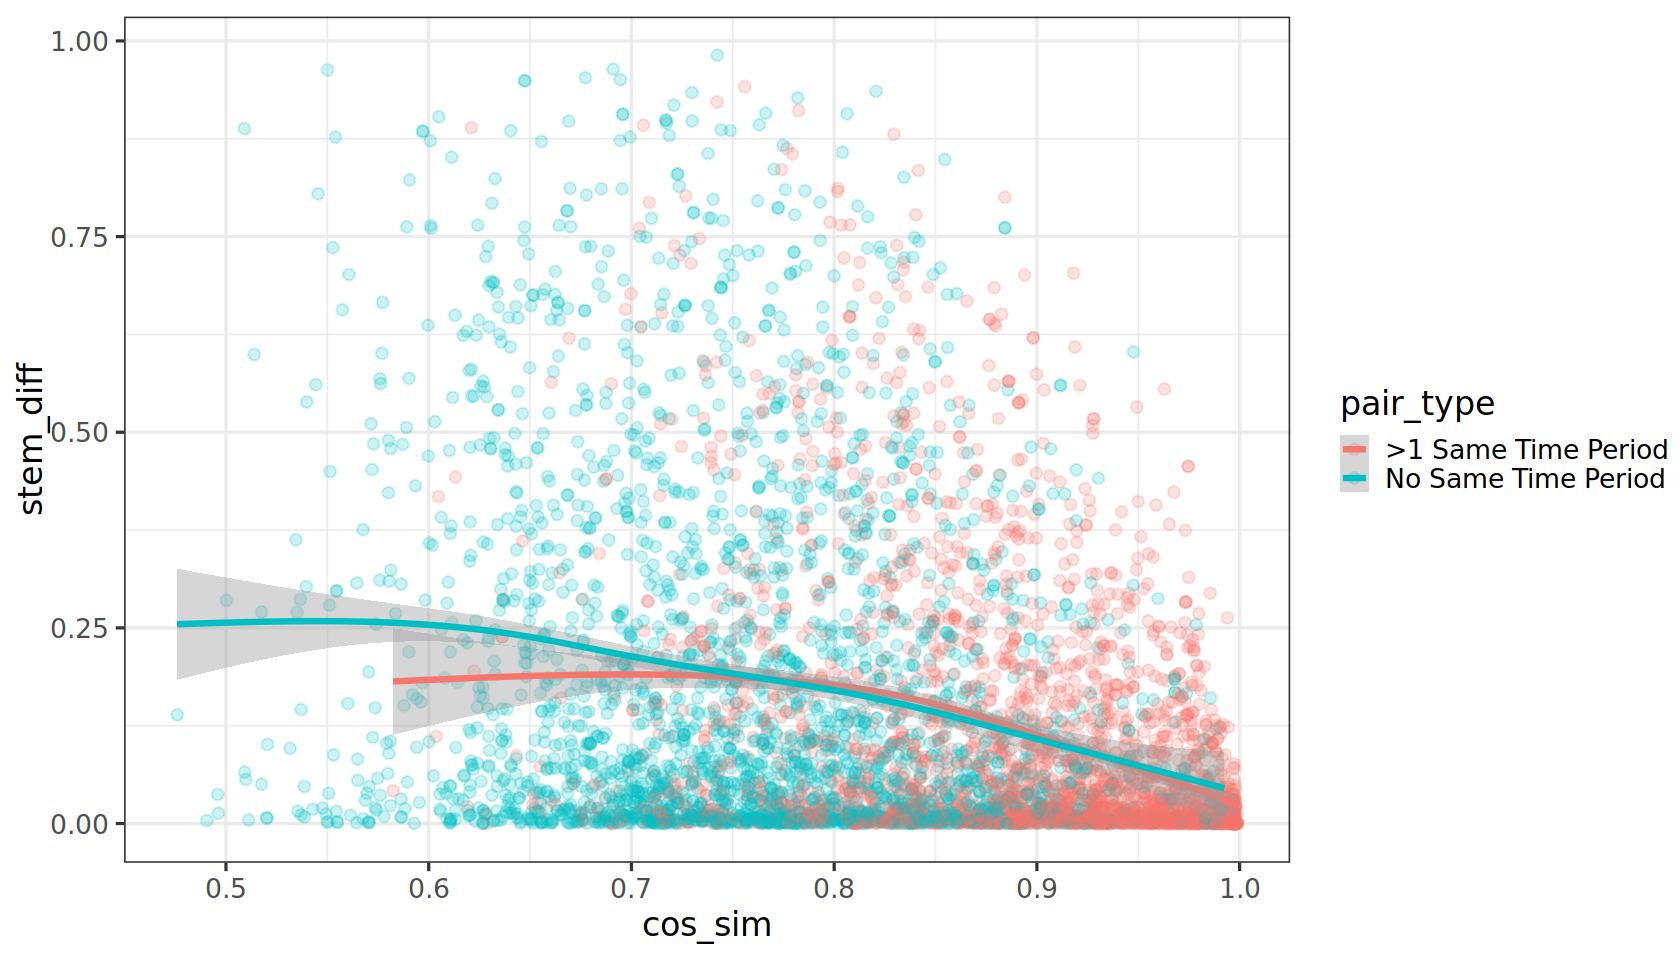

In [8]:
library(repr)
options(repr.plot.width=14, repr.plot.height=8)
ggplot(aff_pair_time, aes(cos_sim,stem_diff, color=pair_type))+geom_point(alpha=.2) + geom_smooth()

# Plots for analysis of Spoon data

In [20]:
library(scales)
######## Checking the classifier #######################
spoon_data_preds <- fread("spoon_data_robustness_check.csv")
spoon_data_preds[, Field := factor(Field,
                                   levels=spoon_data_preds[,mean(preds),
                                                           by=Field][order(V1)]$Field)]

spoon_data_preds[, STEM := ifelse(is_STEM, "STEM\n(from Spoon et al.)", "Non-STEM\n(from Spoon et al.)")]
plt<-ggplot(spoon_data_preds[Field != "",as.list(smean.cl.boot(preds)),by=.(Field,STEM)], 
       aes(Field,
           Mean,ymin=Lower,ymax=Upper))+
  geom_pointrange() + facet_wrap(~STEM,scales="free_y")+
  coord_flip() + geom_hline(yintercept=.5,color='red') +
 scale_y_continuous("Predicted Probability of STEM\nby our Classifier",labels=percent)+
    xlab("Field Name (from Spoon et al.)")

ggsave("spoon_predictions.jpg", plt, h=20,w=18)

In [47]:
library(data.table)
library(ggplot2)

f <- fread("../data/robustness_field_cnt.csv")
# final list of countries for analysis
countr <- fread("./orcid_countrylist.csv")
f <- f[country %in% countr$iso2]


In [51]:
top_250_per_country <- f[, .SD[1:250],by=country][!is.na(clean_affiliation)]

In [52]:
length(unique(top_250_per_country$clean_affiliation))

[1] 14807

In [54]:
flagged <- fread("flagged_manual_removal.csv")
flagged[reason =="not_english"]$reason <- "non_english"
flagged[reason =="not_englis"]$reason <- "non_english"
flagged <- flagged[cmd %in% top_250_per_country$clean_affiliation]
flagged[,.N/length(unique(top_250_per_country$clean_affiliation)), by=reason]

reason,V1
<chr>,<dbl>
not_academic,0.0379550213
both,0.0004052138
non_english,0.0016208550


In [55]:
flagged[,.N,by=reason]

reason,N
<chr>,<int>
not_academic,562
both,6
non_english,24
